In [5]:
#%pip install mlxtend

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [7]:
df = pd.read_csv('./data/orders_data_market_basket_analysis.csv')
df.head()

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit
0,CA-2017-152156,11/8/2017,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2017-152156,11/8/2017,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2017-138688,6/12/2017,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2016-108966,10/11/2016,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2016-108966,10/11/2016,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [10]:
basket = df.groupby('Order ID')['Product Subcategory'].apply(list)
basket.head()

Order ID
CA-2015-100006              [Phones]
CA-2015-100090     [Tables, Binders]
CA-2015-100293               [Paper]
CA-2015-100328             [Binders]
CA-2015-100363    [Fasteners, Paper]
Name: Product Subcategory, dtype: object

In [11]:
te = TransactionEncoder()
te_array = te.fit(basket).transform(basket)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

In [14]:
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
frequent_itemsets.sort_values(by='support', ascending=False, inplace=True)
frequent_itemsets.head()

,support,itemsets
3,0.262727,(Binders)
12,0.237772,(Paper)
9,0.175085,(Furnishings)
13,0.162507,(Phones)
14,0.155121,(Storage)


In [16]:
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x : len(x) == 2)].sort_values(by='support', ascending= False)
top_pairs.head()

,support,itemsets
43,0.054901,"(Binders, Paper)"
44,0.039728,"(Phones, Binders)"
45,0.039728,"(Binders, Storage)"
41,0.039529,"(Binders, Furnishings)"
61,0.035536,"(Storage, Paper)"


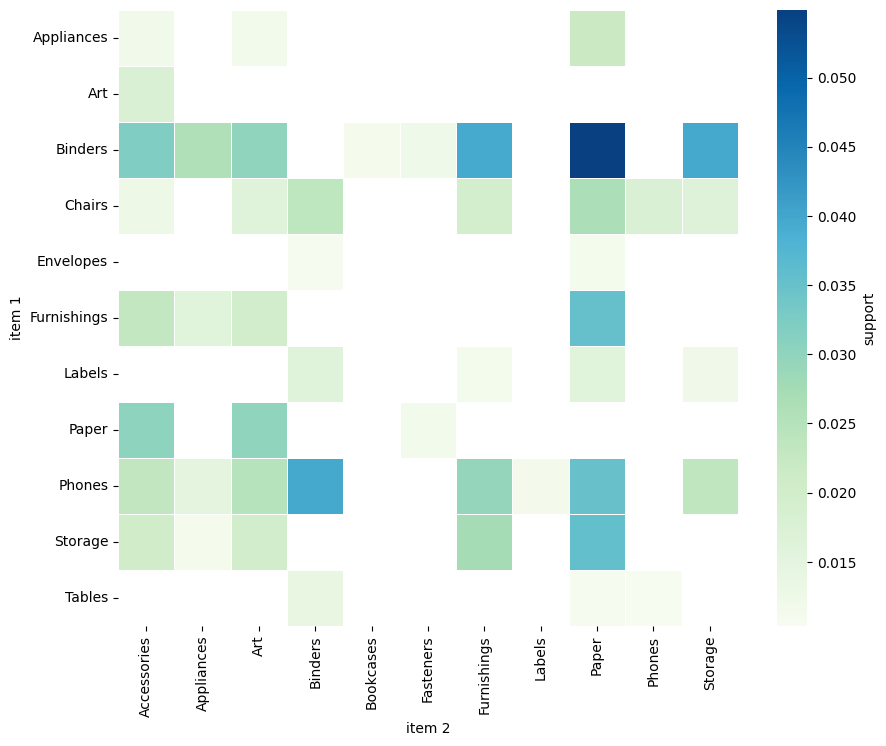

In [21]:
top_pairs['item 1'] = top_pairs['itemsets'].apply(lambda x : list(x)[0])
top_pairs['item 2'] = top_pairs['itemsets'].apply(lambda x : list(x)[1])

heatmap_data = pd.crosstab(top_pairs['item 1'], top_pairs['item 2'], values=top_pairs['support'], aggfunc='sum', dropna=True)

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, annot=False, cmap="GnBu", fmt=".1f", cbar_kws={'label': 'support'}, linewidths=.5)
plt.show()

In [ ]:
# for a pair of 2 items
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x : len(x) == 2)].sort_values(by='support', ascending= False).head(10)

top_pairs['itemsets'] = top_pairs['itemsets'].apply(lambda x: ', '.join(list(x)))
pairs = top_pairs['itemsets'] 
support = top_pairs['support']*100

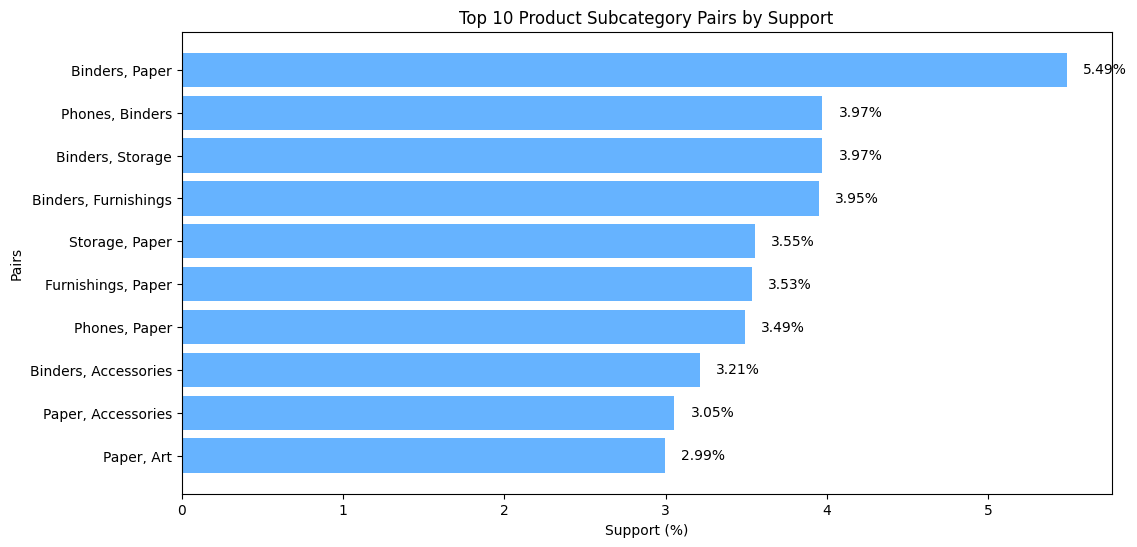

In [26]:
plt.figure(figsize=(12,6))
bars = plt.barh(pairs, support, color='#66b3ff')

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.2f}%', va='center', fontsize= 10, ha='left', color='black')

plt.xlabel('Support (%)')
plt.ylabel('Pairs')
plt.title('Top 10 Product Subcategory Pairs by Support')
plt.gca().invert_yaxis()
plt.show()

In [28]:
# for a pair of 3 items
top_trios = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x : len(x) == 3)].sort_values(by='support', ascending= False).head(10)

top_trios['itemsets'] = top_trios['itemsets'].apply(lambda x: ', '.join(list(x)))
trios = top_trios['itemsets'] 
support = top_trios['support']*100

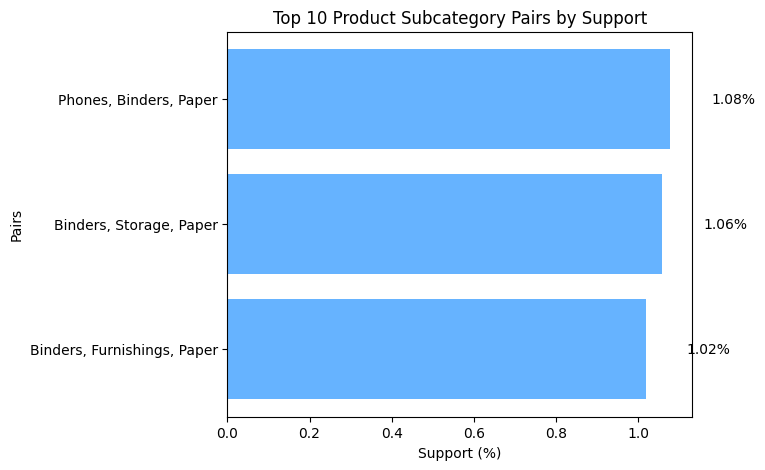

In [31]:
plt.figure(figsize=(6,5))
bars = plt.barh(trios, support, color='#66b3ff')

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.2f}%', va='center', fontsize= 10, ha='left', color='black')

plt.xlabel('Support (%)')
plt.ylabel('Pairs')
plt.title('Top 10 Product Subcategory Pairs by Support')
plt.gca().invert_yaxis()
plt.show()

In [34]:
raw_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = raw_rules[['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
29,"(Binders, Paper)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434
32,(Storage),"(Binders, Paper)",0.155121,0.054901,0.010581,0.068211,1.242434
24,"(Binders, Paper)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336
25,(Phones),"(Binders, Paper)",0.162507,0.054901,0.010781,0.066339,1.208336
26,(Binders),"(Phones, Paper)",0.262727,0.034937,0.010781,0.041033,1.174494
23,"(Phones, Paper)",(Binders),0.034937,0.262727,0.010781,0.308571,1.174494
19,(Fasteners),(Paper),0.042923,0.237772,0.011779,0.274419,1.154125
18,(Paper),(Fasteners),0.237772,0.042923,0.011779,0.049538,1.154125
22,"(Phones, Binders)",(Paper),0.039728,0.237772,0.010781,0.271357,1.141248
27,(Paper),"(Phones, Binders)",0.237772,0.039728,0.010781,0.045340,1.141248
